# SFR Butterfly — Rules of Thumb

The desk card. For every constant-maturity fly slot, 3m and 6m: where it
usually trades, how wide the normal range is, where it is now, how fast it
reverts, and **how far it has to go before fading it has paid net of costs**.

Three things to read before using any number here.

1. **The regime split is load-bearing.** `SFR123` has a median of **+29bp in
   the 2022-23 hiking cycle and −2.5bp in the cutting cycle**. A single
   six-year "typical level" averages incompatible states and is not a level
   anyone should quote. Every table below is therefore given per regime, and
   the unconditional column is shown mainly to demonstrate how misleading it is.

2. **Two band columns, and they answer different questions.** The
   *descriptive* band uses each slot's full-sample median as the reference, so
   it is computed with hindsight and states what *would* have paid — it is the
   "beyond +8 it has historically paid to fade" number, and it is not
   tradeable. The *causal* band uses a trailing median known at the time, so it
   is what an actual rule would have earned. Where the two disagree, believe
   the causal one.

3. **Cost dominates the back of the strip.** A 1/−2/1 SR3 butterfly costs
   **1.5bp** round trip (3 legs × 2 sides × 0.25bp). Slots beyond about SFR789
   have a daily standard deviation under 0.6bp and an interquartile range
   around 1bp, so the entire normal range of the fly is smaller than the cost
   of trading it twice.

In [1]:
CONFIG = dict(
    cost_bp=1.5,
    n_packages=100,
    bands_bp=(0.5, 1, 1.5, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30),
    max_hold=40,
    ref_window=250,        # trailing window for the CAUSAL reference level
    min_trades=10,
    lag=1,
)
CONFIG

{'cost_bp': 1.5,
 'n_packages': 100,
 'bands_bp': (0.5, 1, 1.5, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30),
 'max_hold': 40,
 'ref_window': 250,
 'min_trades': 10,
 'lag': 1}

In [2]:
import sys
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig, run_backtest
from RVUtils.mean_reversion import adf_pvalue, calibrate_ou, half_life
from sfr_fly_meanrev_common import DATA_DIR, REGIME_ORDER, load_lab

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 300)

LABS = {}
for structure in ("3m", "6m"):
    LABS[structure] = load_lab(structure, "liquid16")
    LABS[structure + "_long"] = load_lab(structure, "front8")
print({k: (v["levels"].shape, str(v["levels"].index.min().date()),
           str(v["levels"].index.max().date())) for k, v in LABS.items()})

{'3m': ((1150, 34), '2022-01-03', '2026-07-29'), '3m_long': ((1907, 42), '2019-01-02', '2026-07-29'), '6m': ((1150, 32), '2022-01-03', '2026-07-29'), '6m_long': ((1907, 38), '2019-01-02', '2026-07-29')}


## 1. Where each fly usually trades

On the **constant-maturity** series, which is what a desk means by "the SFR456
fly". It splices contracts every quarter, so it is a reporting object, never a
backtest object.

In [3]:
def level_table(lab, regime=None):
    cm = lab["cm_levels"]
    reg = lab["regimes"].reindex(cm.index)
    rows = []
    for c in cm.columns:
        s = cm[c] if regime is None else cm[c][reg == regime]
        s = s.dropna()
        if len(s) < 60:
            continue
        p = calibrate_ou(s)
        rows.append({"cm": c, "slot": lab["slot_of_label"][c], "n": len(s),
                     "median_bp": s.median(), "mean_bp": s.mean(),
                     "q25": s.quantile(0.25), "q75": s.quantile(0.75),
                     "q05": s.quantile(0.05), "q95": s.quantile(0.95),
                     "sd_bp": s.std(), "iqr_bp": s.quantile(0.75) - s.quantile(0.25),
                     "daily_sd_bp": s.diff().std(),
                     "half_life_d": p["half_life"], "adf_p": adf_pvalue(s)})
    return pd.DataFrame(rows).sort_values("slot")


for structure in ("3m", "6m"):
    lab = LABS[structure]
    print(f"\n{'=' * 100}\n{structure.upper()} FLIES — unconditional "
          f"({lab['levels'].index.min().date()} to "
          f"{lab['levels'].index.max().date()})\n{'=' * 100}")
    t = level_table(lab)
    t["cost_in_iqr"] = CONFIG["cost_bp"] / t["iqr_bp"]
    print(t.round(2).to_string(index=False))


3M FLIES — unconditional (2022-01-03 to 2026-07-29)


          cm  slot    n  median_bp  mean_bp  q25   q75    q05  q95  sd_bp  iqr_bp  daily_sd_bp  half_life_d  adf_p  cost_in_iqr
      SFR123     2 1150        5.0     8.65 -2.5 18.69 -12.14 37.0  15.71   21.19         3.18        33.50   0.03         0.07
      SFR234     3 1150        1.0     2.27 -6.0 10.00 -11.50 20.5  10.60   16.00         1.72        52.70   0.26         0.09
      SFR345     4 1150       -2.5    -0.08 -6.5  5.00  -9.50 17.5   8.45   11.50         1.53        42.20   0.08         0.13
      SFR456     5 1150       -3.5    -1.76 -6.0  1.50  -9.00 12.0   6.45    7.50         1.21        38.88   0.02         0.20
      SFR567     6 1150       -3.5    -3.76 -6.5 -1.50 -12.28  6.5   5.22    5.00         0.98        37.62   0.05         0.30
      SFR678     7 1150       -3.5    -4.29 -7.0 -1.50 -11.50  1.5   4.05    5.50         0.64        47.24   0.24         0.27
      SFR789     8 1149       -2.5    -3.16 -5.0 -1.50  -8.80  0.5   3.21    3.50         0.66        28

          cm  slot    n  median_bp  mean_bp   q25   q75    q05   q95  sd_bp  iqr_bp  daily_sd_bp  half_life_d  adf_p  cost_in_iqr
      SFR135     3 1150       5.13    13.11 -19.0 45.38 -39.27 88.75  42.84   64.38         6.27        64.75   0.29         0.02
      SFR246     4 1150      -8.00     0.36 -24.5 20.00 -34.50 61.00  31.01   44.50         4.82        58.25   0.14         0.03
      SFR357     5 1150     -13.00    -7.36 -23.0  6.00 -34.78 41.50  23.41   29.00         3.99        47.32   0.05         0.05
      SFR468     6 1150     -13.50   -13.57 -24.5 -5.50 -42.50 26.50  18.63   19.00         2.84        55.32   0.06         0.08
      SFR579     7 1149     -13.50   -15.50 -27.5 -6.50 -40.00 11.80  15.33   21.00         1.83        75.52   0.19         0.07
  SFR-6-8-10     8 1149     -10.50   -12.31 -18.5 -5.00 -33.50  0.30  11.47   13.50         1.80        47.24   0.02         0.11
  SFR-7-9-11     9 1149      -6.00    -7.24 -11.0 -2.00 -19.50  1.50   7.03    9.00       

## 2. The same table per policy regime

This is the version to quote.

In [4]:
for structure in ("3m", "6m"):
    lab = LABS[structure + "_long"]     # the long window carries all four regimes
    print(f"\n{'=' * 100}\n{structure.upper()} FLIES — median level (bp) by regime, "
          f"front-8 panel from {lab['levels'].index.min().date()}\n{'=' * 100}")
    parts = {}
    for r in REGIME_ORDER:
        t = level_table(lab, regime=r)
        if t.empty:
            continue
        parts[r] = t.set_index("cm")["median_bp"]
    med = pd.DataFrame(parts)
    med["slot"] = lab["slot_of_label"].reindex(med.index)
    med = med.sort_values("slot").drop(columns="slot")
    # the front-8 panel caps the back leg at slot 8, so deeper slots have no
    # rows in it at all -- drop them rather than print a wall of NaN
    dropped = med.index[med.isna().all(axis=1)].tolist()
    med = med.dropna(how="all")
    med["spread_across_regimes"] = med.max(axis=1) - med.min(axis=1)
    print(med.round(2).to_string())
    if dropped:
        print(f"  (not in the front-8 panel, so no regime history: "
              f"{', '.join(dropped)})")
    print(f"\n  median spread of the 'typical level' across regimes: "
          f"{med['spread_across_regimes'].median():.2f}bp, against a "
          f"{CONFIG['cost_bp']}bp round trip.")


3M FLIES — median level (bp) by regime, front-8 panel from 2019-01-02
        ZIRP  HIKING  PLATEAU  CUTTING  spread_across_regimes
cm                                                           
SFR123  -0.5   29.25      5.0     -2.5                  31.75
SFR234  -0.5   13.75      0.5     -5.5                  19.25
SFR345  -1.0    7.50     -3.0     -6.0                  13.50
SFR456  -1.5    1.00     -5.0     -3.5                   6.00
SFR567  -1.0   -3.50     -6.5     -2.5                   5.50
SFR678  -1.5   -6.50     -7.0     -2.0                   5.50

  median spread of the 'typical level' across regimes: 9.75bp, against a 1.5bp round trip.

6M FLIES — median level (bp) by regime, front-8 panel from 2019-01-02


        ZIRP  HIKING  PLATEAU  CUTTING  spread_across_regimes
cm                                                           
SFR135  -2.5   66.75     4.62    -18.0                  84.75
SFR246  -3.5   33.25   -10.00    -23.5                  56.75
SFR357  -4.5    6.25   -19.00    -16.5                  25.25
SFR468  -4.5   -9.50   -23.75    -10.5                  19.25

  median spread of the 'typical level' across regimes: 41.00bp, against a 1.5bp round trip.


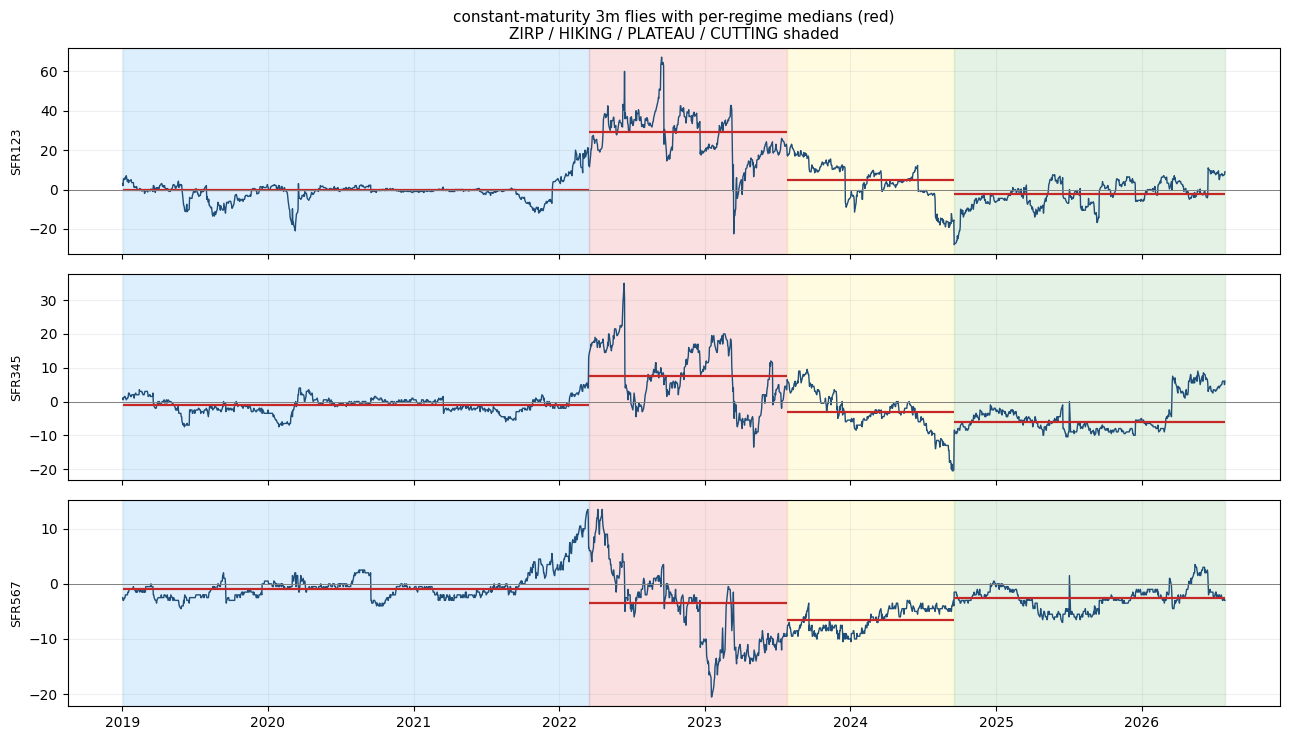

In [5]:
lab = LABS["3m_long"]
cm = lab["cm_levels"]
reg = lab["regimes"].reindex(cm.index)
show = [c for c in cm.columns if lab["slot_of_label"][c] in (2, 4, 6, 8)]
fig, axes = plt.subplots(len(show), 1, figsize=(13, 2.5 * len(show)), sharex=True)
colors = {"ZIRP": "#90caf9", "HIKING": "#ef9a9a", "PLATEAU": "#fff59d",
          "CUTTING": "#a5d6a7"}
for ax, c in zip(np.atleast_1d(axes), show):
    s = cm[c]
    ax.plot(s.index, s.to_numpy(), lw=1.0, color="#1f4e79")
    for r in REGIME_ORDER:
        m = (reg == r).to_numpy()
        if m.any():
            ax.axvspan(s.index[m][0], s.index[m][-1], color=colors[r], alpha=0.30)
            ax.hlines(s[m].median(), s.index[m][0], s.index[m][-1],
                      color="#c62828", lw=1.6)
    ax.axhline(0, color="grey", lw=0.7)
    ax.set_ylabel(c, fontsize=9)
    ax.grid(alpha=0.2)
np.atleast_1d(axes)[0].set_title(
    "constant-maturity 3m flies with per-regime medians (red)\n"
    "ZIRP / HIKING / PLATEAU / CUTTING shaded", fontsize=11)
fig.tight_layout()
plt.show()

## 3. The fade band — how far is far enough?

For each slot and each candidate band `b`, trade the rule: **when the fly is
more than `b` bp away from its reference, fade it; exit when it returns to the
reference, or after 40 days.** Lag-1 fills, 1.5bp charged once per completed
trade. The rule of thumb is the smallest `b` that is net positive with at least
10 trades.

Run on the **absolute** flies (no roll), with each trade attributed to the CM
slot its key occupied on the entry date.

In [6]:
def band_scan(lab, causal: bool):
    """Net P&L by (CM slot, band). causal=False uses the full-sample median."""
    levels, gate = lab["levels"], lab["gate"]
    cm_at = lab["cm_at"]
    if causal:
        ref = levels.rolling(CONFIG["ref_window"],
                             min_periods=CONFIG["ref_window"] // 2).median()
    else:
        # per-KEY full-sample median. Hindsight by construction.
        ref = pd.DataFrame(np.tile(levels.median(axis=0).to_numpy(), (len(levels), 1)),
                           index=levels.index, columns=levels.columns)
    sig = levels - ref
    rows = []
    for b in CONFIG["bands_bp"]:
        cfg = MRConfig(lag=CONFIG["lag"], entry_z=float(b), exit_style="z0",
                       max_hold=CONFIG["max_hold"], direction="fade",
                       round_trip_cost_bp=CONFIG["cost_bp"],
                       n_packages=CONFIG["n_packages"])
        res = run_backtest(cfg, levels=levels, signal=sig, gate=gate)
        if res.trades.empty:
            continue
        tr = res.trades.copy()
        tr["cm"] = [cm_at.at[pd.Timestamp(e), k] if (pd.Timestamp(e) in cm_at.index
                                                     and k in cm_at.columns) else None
                    for e, k in zip(tr["entry"], tr["key"])]
        for cmv, g in tr.groupby("cm"):
            if cmv is None:
                continue
            rows.append({"cm": cmv, "band_bp": b, "n": len(g),
                         "hit": float((g["net_bp"] > 0).mean()),
                         "avg_net_bp": float(g["net_bp"].mean()),
                         "total_net_bp": float(g["net_bp"].sum()),
                         "avg_gross_bp": float(g["gross_bp"].mean()),
                         "avg_hold": float(g["days"].mean())})
    return pd.DataFrame(rows)


def first_paying_band(scan, min_trades):
    rows = []
    for cmv, g in scan.groupby("cm"):
        g = g.sort_values("band_bp")
        ok = g[(g["total_net_bp"] > 0) & (g["n"] >= min_trades)]
        if ok.empty:
            rows.append({"cm": cmv, "paying_band_bp": np.nan, "n": np.nan,
                         "hit": np.nan, "avg_net_bp": np.nan,
                         "total_net_bp": float(g["total_net_bp"].max()),
                         "best_band_bp": float(g.loc[g["total_net_bp"].idxmax(),
                                                     "band_bp"])})
        else:
            r = ok.iloc[0]
            rows.append({"cm": cmv, "paying_band_bp": r["band_bp"], "n": r["n"],
                         "hit": r["hit"], "avg_net_bp": r["avg_net_bp"],
                         "total_net_bp": r["total_net_bp"],
                         "best_band_bp": float(g.loc[g["total_net_bp"].idxmax(),
                                                     "band_bp"])})
    return pd.DataFrame(rows)


band_out = {}
for structure in ("3m", "6m"):
    lab = LABS[structure]
    for causal in (False, True):
        tag = f"{structure}_{'causal' if causal else 'descriptive'}"
        scan = band_scan(lab, causal=causal)
        band_out[tag] = scan
        fp = first_paying_band(scan, CONFIG["min_trades"])
        fp["slot"] = fp["cm"].map(lab["slot_of_label"])
        fp = fp.sort_values("slot")
        print(f"\n{'=' * 96}\n{structure.upper()} — "
              f"{'CAUSAL (trailing median reference)' if causal else 'DESCRIPTIVE (full-sample median, hindsight)'}"
              f"\n{'=' * 96}")
        print(fp.round(3).to_string(index=False))
        n_pay = int(fp["paying_band_bp"].notna().sum())
        print(f"  slots with ANY band that pays net of "
              f"{CONFIG['cost_bp']}bp: {n_pay}/{len(fp)}")


3M — DESCRIPTIVE (full-sample median, hindsight)
          cm  paying_band_bp    n   hit  avg_net_bp  total_net_bp  best_band_bp  slot
      SFR123             NaN  NaN   NaN         NaN          17.5          25.0     2
      SFR234             0.5 51.0 0.471       0.039           2.0           8.0     3
      SFR345             0.5 47.0 0.468       0.234          11.0          12.0     4
      SFR456             4.0 23.0 0.522       0.848          19.5          10.0     5
      SFR567             2.0 31.0 0.452       0.194           6.0           6.0     6
      SFR678             NaN  NaN   NaN         NaN           3.0          10.0     7
      SFR789             NaN  NaN   NaN         NaN          -1.0           8.0     8
  SFR-8-9-10             NaN  NaN   NaN         NaN           7.0           3.0     9
 SFR-9-10-11             NaN  NaN   NaN         NaN           6.0           2.0    10
SFR-10-11-12             NaN  NaN   NaN         NaN           4.0           3.0    11
SFR-


3M — CAUSAL (trailing median reference)
          cm  paying_band_bp    n   hit  avg_net_bp  total_net_bp  best_band_bp  slot
      SFR123             NaN  NaN   NaN         NaN          9.75          25.0     2
      SFR234             2.0 33.0 0.515       0.545         18.00          15.0     3
      SFR345             4.0 18.0 0.500       0.250          4.50           6.0     4
      SFR456             NaN  NaN   NaN         NaN         14.50          10.0     5
      SFR567             4.0 10.0 0.400       1.300         13.00           6.0     6
      SFR678             NaN  NaN   NaN         NaN          0.50          10.0     7
      SFR789             NaN  NaN   NaN         NaN         -1.00          10.0     8
  SFR-8-9-10             NaN  NaN   NaN         NaN         -1.00           8.0     9
 SFR-9-10-11             NaN  NaN   NaN         NaN         -4.50           3.0    10
SFR-10-11-12             NaN  NaN   NaN         NaN          3.00           3.0    11
SFR-11-12-13 


6M — DESCRIPTIVE (full-sample median, hindsight)
          cm  paying_band_bp    n   hit  avg_net_bp  total_net_bp  best_band_bp  slot
      SFR135             3.0 47.0 0.617       0.691          32.5          10.0     3
      SFR246             0.5 54.0 0.741       4.694         253.5           6.0     4
      SFR357             0.5 60.0 0.683       3.275         196.5           0.5     5
      SFR468             0.5 50.0 0.540       2.010         100.5          15.0     6
      SFR579             6.0 30.0 0.467       0.200           6.0          10.0     7
  SFR-6-8-10             NaN  NaN   NaN         NaN          -2.0          30.0     8
  SFR-7-9-11             3.0 27.0 0.481       0.204           5.5          15.0     9
 SFR-8-10-12             0.5 51.0 0.333       0.775          39.5           4.0    10
 SFR-9-11-13             5.0 12.0 0.333       0.375           4.5          12.0    11
SFR-10-12-14             3.0 15.0 0.333       0.200           3.0           8.0    12
SFR-


6M — CAUSAL (trailing median reference)
          cm  paying_band_bp    n   hit  avg_net_bp  total_net_bp  best_band_bp  slot
      SFR135             6.0 37.0 0.622       0.885         32.75          10.0     3
      SFR246             0.5 40.0 0.600       2.038         81.50           0.5     4
      SFR357            20.0 16.0 0.562       2.469         39.50          30.0     5
      SFR468             0.5 52.0 0.635       0.990         51.50           4.0     6
      SFR579             8.0 14.0 0.357       1.250         17.50          12.0     7
  SFR-6-8-10             NaN  NaN   NaN         NaN         -7.00          30.0     8
  SFR-7-9-11             NaN  NaN   NaN         NaN         11.50          20.0     9
 SFR-8-10-12             NaN  NaN   NaN         NaN         23.00          12.0    10
 SFR-9-11-13             2.0 30.0 0.533       0.133          4.00           3.0    11
SFR-10-12-14             3.0 10.0 0.500       0.650          6.50           4.0    12
SFR-11-13-15 

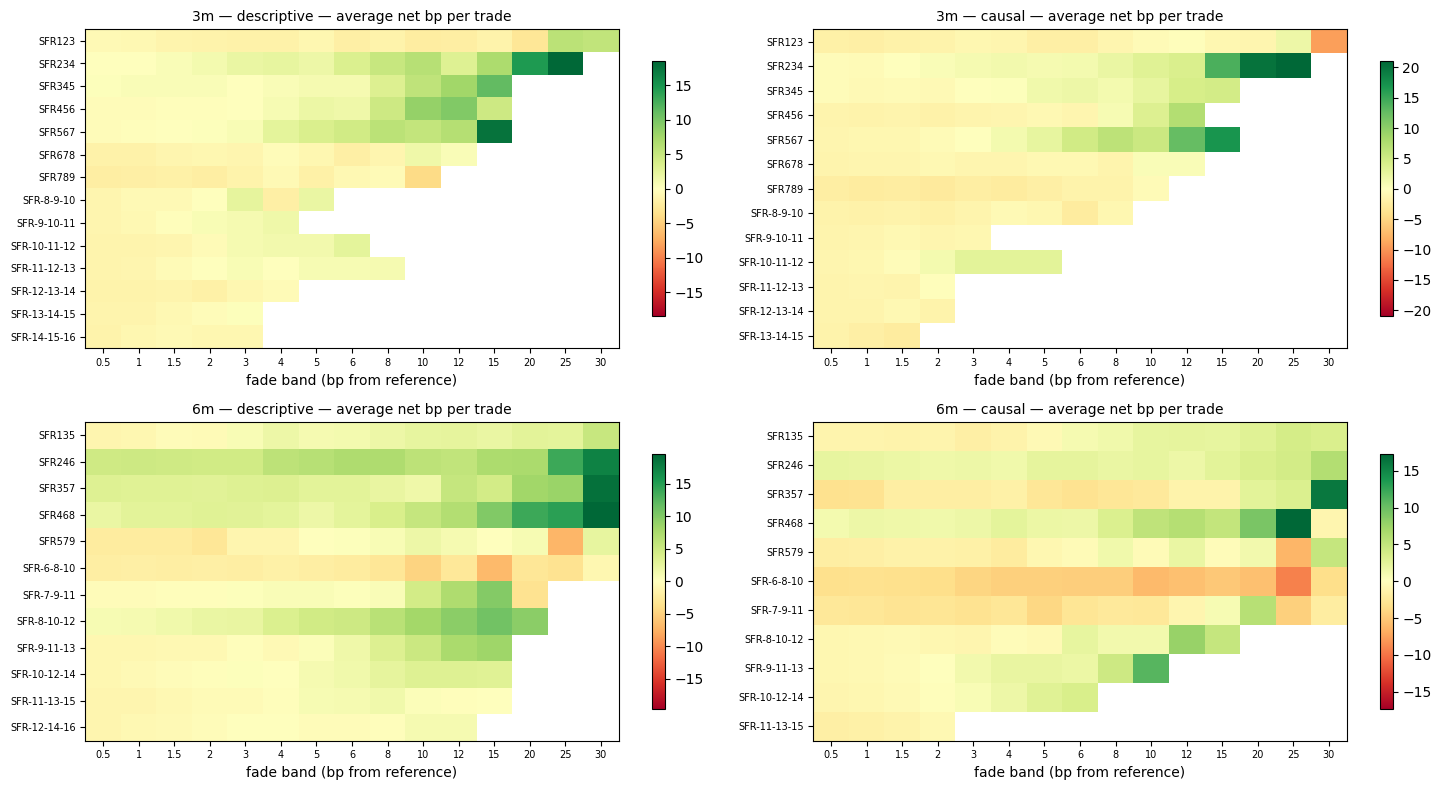

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for i, structure in enumerate(("3m", "6m")):
    for j, causal in enumerate((False, True)):
        scan = band_out[f"{structure}_{'causal' if causal else 'descriptive'}"]
        ax = axes[i][j]
        if scan.empty:
            continue
        piv = scan.pivot_table(index="cm", columns="band_bp", values="avg_net_bp")
        slot = LABS[structure]["slot_of_label"].reindex(piv.index)
        piv = piv.loc[slot.sort_values().index]
        v = np.nanmax(np.abs(piv.to_numpy(dtype=float)))
        im = ax.imshow(piv.to_numpy(dtype=float), aspect="auto", cmap="RdYlGn",
                       vmin=-v, vmax=v)
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels([f"{c:g}" for c in piv.columns], fontsize=7)
        ax.set_yticks(range(len(piv)))
        ax.set_yticklabels(piv.index, fontsize=7)
        ax.set_xlabel("fade band (bp from reference)")
        ax.set_title(f"{structure} — {'causal' if causal else 'descriptive'} — "
                     f"average net bp per trade", fontsize=10)
        fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

## 4. The card

Everything a desk needs on one row per slot: where it sits, how wide it swings,
how fast it reverts, where it is today, and the band beyond which fading it has
paid.

In [8]:
cards = []
for structure in ("3m", "6m"):
    lab = LABS[structure]
    lab_long = LABS[structure + "_long"]
    base = level_table(lab).set_index("cm")
    causal = first_paying_band(band_out[f"{structure}_causal"],
                               CONFIG["min_trades"]).set_index("cm")
    desc = first_paying_band(band_out[f"{structure}_descriptive"],
                             CONFIG["min_trades"]).set_index("cm")
    cm = lab["cm_levels"]
    last_date = cm.dropna(how="all").index[-1]
    cur = cm.loc[last_date]
    z = ((cur - cm.median()) / cm.std())
    reg_med = {}
    for r in REGIME_ORDER:
        t = level_table(lab_long, regime=r)
        if not t.empty:
            reg_med[r] = t.set_index("cm")["median_bp"]
    for c in base.index:
        row = {"structure": structure, "cm": c, "slot": base.loc[c, "slot"],
               "typical_bp": base.loc[c, "median_bp"],
               "iqr_bp": base.loc[c, "iqr_bp"],
               "p05_bp": base.loc[c, "q05"], "p95_bp": base.loc[c, "q95"],
               "daily_sd_bp": base.loc[c, "daily_sd_bp"],
               "half_life_d": base.loc[c, "half_life_d"],
               "current_bp": float(cur.get(c, np.nan)),
               "current_z": float(z.get(c, np.nan)),
               "fade_band_causal_bp": causal["paying_band_bp"].get(c, np.nan),
               "hit_at_band": causal["hit"].get(c, np.nan),
               "n_at_band": causal["n"].get(c, np.nan),
               "avg_net_at_band_bp": causal["avg_net_bp"].get(c, np.nan),
               "fade_band_descriptive_bp": desc["paying_band_bp"].get(c, np.nan)}
        for r in REGIME_ORDER:
            row[f"median_{r}"] = (float(reg_med[r].get(c, np.nan))
                                  if r in reg_med else np.nan)
        cards.append(row)
card = pd.DataFrame(cards).sort_values(["structure", "slot"])
print(f"as of {last_date.date()}\n")
print(card.round(2).to_string(index=False))
card.to_csv(DATA_DIR / "rules_of_thumb.csv", index=False)
print(f"\nwrote {DATA_DIR / 'rules_of_thumb.csv'}")

as of 2026-07-29

structure           cm  slot  typical_bp  iqr_bp  p05_bp  p95_bp  daily_sd_bp  half_life_d  current_bp  current_z  fade_band_causal_bp  hit_at_band  n_at_band  avg_net_at_band_bp  fade_band_descriptive_bp  median_ZIRP  median_HIKING  median_PLATEAU  median_CUTTING
       3m       SFR123     2        5.00   21.19  -12.14   37.00         3.18        33.50         9.0       0.25                  NaN          NaN        NaN                 NaN                       NaN         -0.5          29.25            5.00            -2.5
       3m       SFR234     3        1.00   16.00  -11.50   20.50         1.72        52.70         8.5       0.71                  2.0         0.52       33.0                0.55                       0.5         -0.5          13.75            0.50            -5.5
       3m       SFR345     4       -2.50   11.50   -9.50   17.50         1.53        42.20         6.0       1.01                  4.0         0.50       18.0                0.25         

## 5. The card in words

In [9]:
print(f"SFR BUTTERFLY RULES OF THUMB — as of {last_date.date()}")
print(f"1 package = 4 contracts = $25/bp. Round trip {CONFIG['cost_bp']}bp.")
print("=" * 100)
for structure in ("3m", "6m"):
    print(f"\n--- {structure} flies ---")
    for _, r in card[card["structure"] == structure].iterrows():
        band = r["fade_band_causal_bp"]
        rng = f"{r['p05_bp']:+.0f} to {r['p95_bp']:+.0f}"
        line = (f"  {r['cm']:<14s} typically {r['typical_bp']:+5.1f}bp "
                f"(90% range {rng:>12s}, IQR {r['iqr_bp']:4.1f}bp, "
                f"half-life {r['half_life_d']:5.1f}d) | "
                f"now {r['current_bp']:+6.1f}bp (z {r['current_z']:+.2f})")
        if np.isfinite(band):
            line += (f" | FADE beyond +/-{band:.1f}bp "
                     f"(hit {r['hit_at_band']:.0%} over "
                     f"{int(r['n_at_band']) if np.isfinite(r['n_at_band']) else 0} "
                     f"trades)")
        else:
            line += " | NO band pays net of costs"
        print(line)
    hikes = card[card["structure"] == structure]
    cols_r = [f"median_{r}" for r in REGIME_ORDER]
    hikes = hikes[["cm"] + cols_r].dropna(subset=cols_r, how="all")
    if not hikes.empty:
        print(f"\n  regime medians ({structure}, front-8 panel only):")
        print("  " + hikes.round(1).to_string(index=False).replace("\n", "\n  "))

SFR BUTTERFLY RULES OF THUMB — as of 2026-07-29
1 package = 4 contracts = $25/bp. Round trip 1.5bp.

--- 3m flies ---
  SFR123         typically  +5.0bp (90% range   -12 to +37, IQR 21.2bp, half-life  33.5d) | now   +9.0bp (z +0.25) | NO band pays net of costs
  SFR234         typically  +1.0bp (90% range   -12 to +20, IQR 16.0bp, half-life  52.7d) | now   +8.5bp (z +0.71) | FADE beyond +/-2.0bp (hit 52% over 33 trades)
  SFR345         typically  -2.5bp (90% range    -9 to +17, IQR 11.5bp, half-life  42.2d) | now   +6.0bp (z +1.01) | FADE beyond +/-4.0bp (hit 50% over 18 trades)
  SFR456         typically  -3.5bp (90% range    -9 to +12, IQR  7.5bp, half-life  38.9d) | now   +2.0bp (z +0.85) | NO band pays net of costs
  SFR567         typically  -3.5bp (90% range    -12 to +7, IQR  5.0bp, half-life  37.6d) | now   -3.0bp (z +0.10) | FADE beyond +/-4.0bp (hit 40% over 10 trades)
  SFR678         typically  -3.5bp (90% range    -11 to +1, IQR  5.5bp, half-life  47.2d) | now   -2.0bp (z

## 6. The tick lattice — why the back of the strip only *looks* fast

SR3 settles on a 0.005 price grid outside its final four months (0.0025 inside),
which is **0.5bp of rate**. A fly is a weighted sum of three settles, so it
inherits that lattice. When a fly's entire standard deviation is around one
tick, the series is a 3-5 point lattice — and every mean-reversion estimator
reads a lattice as strongly reverting. None of it is tradeable, because one
tick *is* 0.5bp and the round trip is three ticks.

In [10]:
lab = LABS["3m"]
st = lab["struct"]
TICK = 0.5
rows = []
for cm, g in st.groupby("cm_label_short"):
    v = g["value"].dropna()
    if len(v) < 200:
        continue
    dv = g.sort_values(["key", "as_of"]).groupby("key")["value"].diff().dropna()
    rows.append({"cm": cm, "slot": g["cm_slot"].iloc[0], "sd_bp": v.std(),
                 "sd_in_ticks": v.std() / TICK,
                 "n_distinct_values": v.nunique(),
                 "pct_days_unchanged": float((dv.abs() < 1e-9).mean()),
                 "pct_days_within_1_tick": float((dv.abs() <= TICK + 1e-9).mean()),
                 "half_life_d": half_life(v)})
tick = pd.DataFrame(rows).sort_values("slot")
print(tick.round(3).to_string(index=False))
print(f"\n  the half-life falls monotonically from {tick['half_life_d'].iloc[0]:.1f}d "
      f"to {tick['half_life_d'].iloc[-1]:.1f}d as sd/tick falls from "
      f"{tick['sd_in_ticks'].iloc[0]:.1f} to {tick['sd_in_ticks'].iloc[-1]:.1f}. "
      f"That is discretisation, not economics.")
lattice = tick[tick["sd_in_ticks"] < 2.0]
print(f"  slots whose whole standard deviation is under two ticks: "
      f"{', '.join(lattice['cm']) if len(lattice) else 'none'}")

          cm  slot  sd_bp  sd_in_ticks  n_distinct_values  pct_days_unchanged  pct_days_within_1_tick  half_life_d
      SFR123     2 15.710       31.420                452               0.129                   0.419       33.504
      SFR234     3 10.595       21.191                253               0.216                   0.555       52.699
      SFR345     4  8.447       16.894                211               0.251                   0.619       42.199
      SFR456     5  6.453       12.907                191               0.316                   0.690       38.879
      SFR567     6  5.216       10.433                169               0.327                   0.749       37.615
      SFR678     7  4.047        8.094                134               0.390                   0.844       47.242
      SFR789     8  3.206        6.413                115               0.420                   0.881       28.497
  SFR-8-9-10     9  1.787        3.574                 70               0.412   

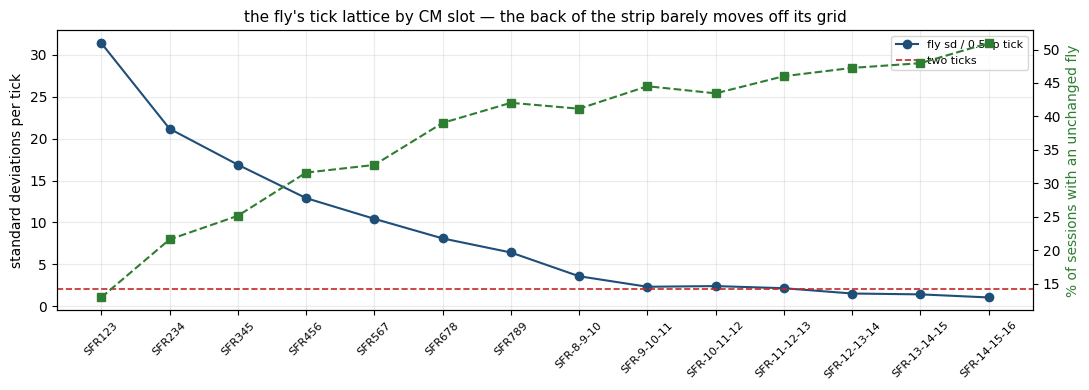

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tick["cm"], tick["sd_in_ticks"], "o-", color="#1f4e79",
        label="fly sd / 0.5bp tick")
ax.axhline(2.0, color="#c62828", ls="--", lw=1.2, label="two ticks")
ax.set_ylabel("standard deviations per tick")
ax2 = ax.twinx()
ax2.plot(tick["cm"], tick["pct_days_unchanged"] * 100, "s--", color="#2e7d32",
         label="% days unchanged")
ax2.set_ylabel("% of sessions with an unchanged fly", color="#2e7d32")
ax.set_title("the fly's tick lattice by CM slot — the back of the strip barely "
             "moves off its grid", fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 7. Health warning

Read this before quoting anything above.

In [12]:
n_slots = len(card)
n_pay = int(card["fade_band_causal_bp"].notna().sum())
spread = (card[[f"median_{r}" for r in REGIME_ORDER]].max(axis=1)
          - card[[f"median_{r}" for r in REGIME_ORDER]].min(axis=1))
print(f"* {n_pay} of {n_slots} constant-maturity slots have ANY causal fade band "
      f"that pays net of {CONFIG['cost_bp']}bp.")
print(f"* The 'typical level' moves by a median of {spread.median():.1f}bp across "
      f"policy regimes, against a {CONFIG['cost_bp']}bp round trip. For "
      f"{int((spread > CONFIG['cost_bp']).sum())} of {n_slots} slots the "
      f"regime-to-regime shift in the fair level is larger than the entire cost "
      f"of the trade, so the unconditional median is not a fair value.")
tight = card[card["iqr_bp"] < CONFIG["cost_bp"]]
print(f"* {len(tight)} slots have an interquartile range narrower than the "
      f"{CONFIG['cost_bp']}bp round trip: "
      f"{', '.join(tight['cm'].tolist()) if len(tight) else 'none'}.")
print("* The descriptive band uses the full-sample median and is therefore "
      "computed with hindsight. Where it disagrees with the causal band, the "
      "causal one is the tradeable number.")
print(f"* {len(lattice)} slots are effectively a tick lattice (standard deviation "
      f"under two 0.5bp ticks): "
      f"{', '.join(lattice['cm']) if len(lattice) else 'none'}. Their short "
      f"fitted half-lives are discretisation, not reversion, and should not be "
      f"used to set a holding period.")

* 10 of 26 constant-maturity slots have ANY causal fade band that pays net of 1.5bp.
* The 'typical level' moves by a median of 19.3bp across policy regimes, against a 1.5bp round trip. For 10 of 26 slots the regime-to-regime shift in the fair level is larger than the entire cost of the trade, so the unconditional median is not a fair value.
* 6 slots have an interquartile range narrower than the 1.5bp round trip: SFR-9-10-11, SFR-10-11-12, SFR-11-12-13, SFR-12-13-14, SFR-13-14-15, SFR-14-15-16.
* The descriptive band uses the full-sample median and is therefore computed with hindsight. Where it disagrees with the causal band, the causal one is the tradeable number.
* 3 slots are effectively a tick lattice (standard deviation under two 0.5bp ticks): SFR-12-13-14, SFR-13-14-15, SFR-14-15-16. Their short fitted half-lives are discretisation, not reversion, and should not be used to set a holding period.
